# Strategy 01: Baseline Without Balancing

Establishes reference metrics by training on a naturally imbalanced dataset with no balancing strategy. Demonstrates how class imbalance degrades Macro-F1 and inflates TPRGap.

In [1]:
import sys
import os
import json

# Local imports
sys.path.append(os.path.abspath(".."))

from src.paths import MODELS_DIR
from src.plot_utils import plot_metrics, results_to_dataframe

/home/phmgc/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Results

In [2]:
eval_results_file = MODELS_DIR / "baseline" / "eval_results.json"

if not eval_results_file.exists():
    raise FileNotFoundError(f"Evaluation results not found at {eval_results_file}. Run scripts/eval.py first.")

with open(eval_results_file, "r") as f:
    results = json.load(f)

print(f"Loaded results for {len(results)} datasets.")

Loaded results for 5 datasets.


In [3]:
results_to_dataframe(results).round(4)

,accuracy,macro_f1,tpr_class_0,tpr_class_1,tpr_gap,imbalance_ratio
dataset,,,,,,
cds_reviews,0.9256,0.4807,0.0000,1.0000,1.0000,12.3464
digital_music,0.9566,0.4889,0.0000,1.0000,1.0000,21.8872
sentistrength_myspace,0.9341,0.8532,0.6667,0.9790,0.3124,5.3182
imdb,0.8723,0.8712,0.7789,0.9657,0.1868,1.0000
luxury_beauty,0.9783,0.9574,0.9362,0.9856,0.0494,5.6549


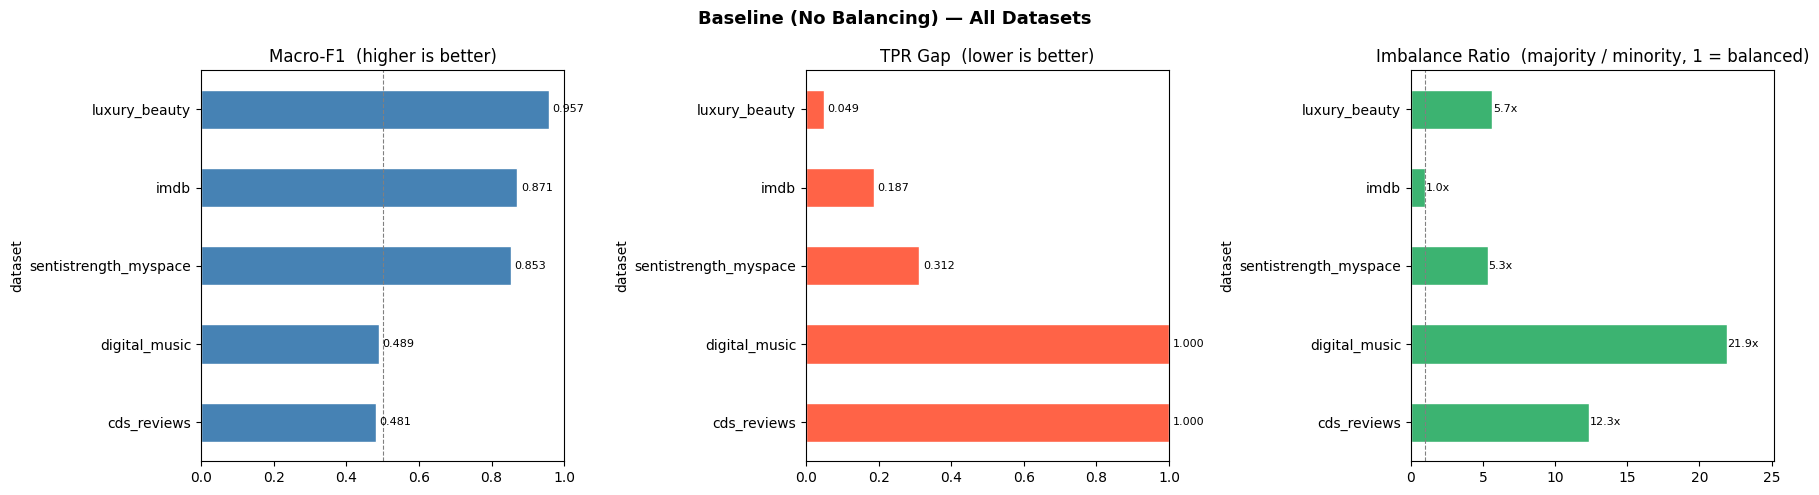

In [4]:
plot_metrics(results, title="Baseline (No Balancing) — All Datasets")

## Conclusion

When class imbalance is severe, **TPRGap increases sharply** even when **accuracy remains high**, indicating strong bias toward the majority class.  
When imbalance is moderate or low, the model can learns both classes reasonably well, resulting in a low TPRGap and better-balanced performance (higher Macro-F1).